# GBRBM

<img src="/Users/test/Desktop/Master/Advanced_topics_in_PoD/project_code/GBRM_diagram.png" width="600"/>

In [286]:
from RBMS import MixedRBM
from helpers import read_data
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import pickle
from scipy.special import softmax
rng = np.random.default_rng(42)

### WHY GBRMBM?

In [310]:
zero_days = (real_den == 0).sum(axis=0)
zero_pct  = 100 * zero_days / T

for i, sp in enumerate(species):
    print(f"{sp:<40s}  zero days: {zero_days[i]:4d}  ({zero_pct[i]:.1f}%)")

aphanizomenon                             zero days:  149  (7.2%)
askenasia                                 zero days:  472  (22.8%)
asplanchna                                zero days:  300  (14.5%)
asterionella                              zero days:  348  (16.8%)
aulacoseira                               zero days:  215  (10.4%)
bosmina                                   zero days:  734  (35.5%)
centric_diatom                            zero days:   18  (0.9%)
ceratium                                  zero days:  202  (9.8%)
chaoborus                                 zero days: 1575  (76.2%)
chlorophyte                               zero days:   13  (0.6%)
chlorophyte_colonial_dividing             zero days:   13  (0.6%)
chlorophyte_elongated                     zero days:   65  (3.1%)
chlorophyte_frame                         zero days:  617  (29.9%)
chlorophyte_square                        zero days:  127  (6.1%)
chroococcales                             zero days:  664  (32.1%)
ch

In [289]:
import os
print(os.getcwd())
print("GBRBM_diagram.png" in os.listdir('.'))

/Users/test/Desktop/Master/Advanced_topics_in_PoD/project_code
False


In [287]:
#Load Data
X, X_raw, real_den, dates, species = read_data()
T, n_vis = X.shape
print(f"Loaded {T} time steps, {n_vis} variables")

Loaded 2066 time steps, 81 variables


### 1. Data Preparation
 
Each timestep `t` has two views of the same observation:
- **`Vb[t]`** — binary presence/absence vector (`1` if detected, `0` otherwise)
- **`Vg[t]`** — Gaussian log-abundance vector (continuous, normalized counts)

In [ ]:
Vb = (real_den > 0).astype(np.float32) # Binary visibility
Vg = X                                    # Gaussian visibility

### 2. Train/Validation Split
 
80/20 random split. Both arrays are shuffled with the **same permutation** so `Vb_train[i]` always pairs with `Vg_train[i]`.

In [ ]:
perm  = rng.permutation(T)
split = int(0.8 * T)
Vb_train, Vb_val = Vb[perm[:split]], Vb[perm[split:]]
Vg_train, Vg_val = Vg[perm[:split]], Vg[perm[split:]]

### 3. Hyperparameters
 
| Parameter            | Value         | Role                             |
|----------------------|---------------|----------------------------------|
| `GBRBM_EPOCHS`       | 3000          | Max epochs per model             |
| `GBRBM_PATIENCE`     | 100           | Early stopping patience          |
| `RBM_LR`             | 1e-3          | Base learning rate               |
| `RBM_BATCH`          | 32            | Mini-batch size                  |
| `GBRBM_HIDDEN_SWEEP` | [5, 15, …205] | Hidden unit counts to sweep over |
 
---

In [ ]:
GBRBM_EPOCHS        = 3000
GBRBM_PATIENCE      = 100
RBM_LR              = 1e-3
RBM_BATCH           = 32
GBRBM_HIDDEN_SWEEP  = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205]

### 4. Validation Metric — `mixed_val_mse`
 
One-step encode → decode reconstruction:
1. **Encode** [h_given_v(Vb, Vg)](cci:1://file:///Users/test/Desktop/Master/Advanced_topics_in_PoD/project_code/RBMS.py:136:4-137:61) → hidden probabilities `h`
2. **Decode** [vg_mean_given_h(h)](cci:1://file:///Users/test/Desktop/Master/Advanced_topics_in_PoD/project_code/RBMS.py:142:4-143:56) → reconstructed Gaussian visible
3. **Error** MSE between reconstruction and true `Vg`
 
Only the Gaussian channel is evaluated — the harder, more informative one.
$$
\text{MSE}_{\text{val}} = \frac{1}{T_{\text{val}}} \sum_{t=1}^{T_{\text{val}}} \frac{1}{V} \sum_{i=1}^{V} \left( v^{(t)}_{g,i} - \sigma^2 \left( W_g^\top h^{(t)} + b_g \right)_i \right)^2
$$

where $h^{(t)} = \sigma\!\left( W_b\, v^{(t)}_b + W_g\, v^{(t)}_g + b_h \right)$

 
| Symbol | Meaning |
|---|---|
| $T_{\text{val}}$ | Number of validation timesteps |
| $V$ | Number of taxa; the visible layer has size $2V$ ($V$ binary + $V$ Gaussian) |
| $v^{(t)}_{g,i}$ | True log-abundance of taxon $i$ at time $t$ |
| $v^{(t)}_b$ | Binary presence/absence vector at time $t$ |
| $v^{(t)}_g$ | Gaussian log-abundance vector at time $t$ |
| $h^{(t)}$ | Hidden unit activation probabilities at time $t$ |
| $W_b$ | Weights connecting binary visibles to hidden units |
| $W_g$ | Weights connecting Gaussian visibles to hidden units |
| $b_h$ | Hidden bias vector - shifts how easely hidden units activate |
| $b_g$ | Gaussian visible bias vector - shifts the mean of the Gaussian distribution |
| $\sigma(\cdot)$ | Element-wise sigmoid function |
| $\sigma^2$ | Fixed variance of the Gaussian visible units (here $\sigma^2 = 1$) |


In [ ]:
def mixed_val_mse(model, Vb_v, Vg_v):
    errs = [float(np.mean((Vg_v[t] - model.vg_mean_given_h(
                model.h_given_v(Vb_v[t], Vg_v[t]))) ** 2))
            for t in range(len(Vg_v))]
    return float(np.mean(errs))

### 5. Hidden-Unit Sweep
 
The learning rate is **scaled down** as `lr = RBM_LR / sqrt(n_hidden / 5)` to compensate for larger gradient magnitudes in bigger models.
 
Each candidate is trained with:
- **CD-1** — one sample at a time (online within mini-batch)
- **Early stopping** — weights snapshotted on improvement, halting after 100 stale epochs

In [ ]:
# ── Sweep ─────────────────────────────────────────────────────────────────────
best_overall_val  = np.inf
best_hidden_units = None
best_model_snap   = None

sweep_results = []
for n_hidden in GBRBM_HIDDEN_SWEEP:
    lr        = RBM_LR / np.sqrt(n_hidden / 5)   # scale lr down for larger models
    rbm       = MixedRBM(n_vis, n_hidden, lr=lr, momentum=0.9, l2=1e-4)
    train_his = []
    val_his   = []
    best_val  = np.inf
    best_snap = None
    no_imp    = 0

    for epoch in range(GBRBM_EPOCHS):
        idx       = rng.permutation(len(Vb_train))
        epoch_mse = []
        for start in range(0, len(idx), RBM_BATCH):
            for t in idx[start : start + RBM_BATCH]:
                epoch_mse.append(rbm.cd1_step(Vb_train[t], Vg_train[t]))
        train_his.append(float(np.mean(epoch_mse)))

        val_mse = mixed_val_mse(rbm, Vb_val, Vg_val)
        val_his.append(val_mse)

        if val_mse < best_val:
            best_val  = val_mse
            best_snap = {k: getattr(rbm, k).copy()
                         for k in ('Wb', 'Wg', 'bb', 'bg', 'bh')}
            no_imp    = 0
        else:
            no_imp += 1
        if no_imp >= GBRBM_PATIENCE:
            break

    if best_snap:
        for k, v in best_snap.items():
            setattr(rbm, k, v)

    print(f"n_hidden={n_hidden:4d} | lr={lr:.2e} | best_val={best_val:.4f} | epochs={len(val_his)}")

    if best_val < best_overall_val:
        best_overall_val  = best_val
        best_hidden_units = n_hidden
        best_model_snap   = best_snap | {'n_hidden': n_hidden}

    sweep_results.append({
        'n_hidden': n_hidden,
        'lr': lr,
        'best_val': best_val,
        'epochs': len(val_his),
        'train_history': train_his.copy(),
        'val_history': val_his.copy(),
        'snap': best_snap
    })

print(f"\nBest: n_hidden={best_hidden_units}  val_MSE={best_overall_val:.4f}")

# ── Reconstruct winner ────────────────────────────────────────────────────────
rbm_best = MixedRBM(n_vis, best_hidden_units, lr=RBM_LR, momentum=0.9, l2=1e-4)
for k in ('Wb', 'Wg', 'bb', 'bg', 'bh'):
    setattr(rbm_best, k, best_model_snap[k])

KeyboardInterrupt: 

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
GBRBM_EPOCHS   = 1000
GBRBM_PATIENCE = 100
RBM_LR         = 1e-3
RBM_BATCH      = 32
n_hidden       = 65

best_overall_val  = np.inf
best_hidden_units = None
best_model_snap   = None

lr        = RBM_LR / np.sqrt(n_hidden / 5)
rbm       = MixedRBM(n_vis, n_hidden, lr=lr, momentum=0.9, l2=1e-4)
train_his = []
val_his   = []
best_val  = np.inf
best_snap = None
no_imp    = 0

for epoch in range(GBRBM_EPOCHS):
    idx       = rng.permutation(len(Vb_train))
    epoch_mse = []
    for start in range(0, len(idx), RBM_BATCH):
        for t in idx[start : start + RBM_BATCH]:
            epoch_mse.append(rbm.cd1_step(Vb_train[t], Vg_train[t]))
    train_his.append(float(np.mean(epoch_mse)))

    val_mse = mixed_val_mse(rbm, Vb_val, Vg_val)
    val_his.append(val_mse)

    if val_mse < best_val:
        best_val  = val_mse
        best_snap = {k: getattr(rbm, k).copy()
                     for k in ('Wb', 'Wg', 'bb', 'bg', 'bh')}
        no_imp    = 0
    else:
        no_imp += 1

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | train={train_his[-1]:.4f} | val={val_mse:.4f} | best={best_val:.4f} | no_imp={no_imp}")

    if no_imp >= GBRBM_PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_snap:
    for k, v in best_snap.items():
        setattr(rbm, k, v)

rbm65       = rbm
best_snap65 = best_snap

Epoch   50 | train=0.2215 | val=0.2377 | best=0.2338 | no_imp=5
Epoch  100 | train=0.2094 | val=0.2300 | best=0.2233 | no_imp=6
Epoch  150 | train=0.2025 | val=0.2205 | best=0.2159 | no_imp=2
Epoch  200 | train=0.1987 | val=0.2152 | best=0.2117 | no_imp=5
Epoch  250 | train=0.1964 | val=0.2117 | best=0.2071 | no_imp=1
Epoch  300 | train=0.1926 | val=0.2079 | best=0.2062 | no_imp=7
Epoch  350 | train=0.1904 | val=0.2048 | best=0.2036 | no_imp=24
Epoch  400 | train=0.1888 | val=0.2047 | best=0.2026 | no_imp=25
Epoch  450 | train=0.1870 | val=0.2062 | best=0.2018 | no_imp=2
Epoch  500 | train=0.1852 | val=0.2067 | best=0.1990 | no_imp=19
Epoch  550 | train=0.1843 | val=0.2008 | best=0.1965 | no_imp=10
Epoch  600 | train=0.1826 | val=0.1959 | best=0.1957 | no_imp=48
Epoch  650 | train=0.1815 | val=0.1963 | best=0.1955 | no_imp=31
Epoch  700 | train=0.1812 | val=0.1990 | best=0.1943 | no_imp=47
Epoch  750 | train=0.1791 | val=0.1967 | best=0.1931 | no_imp=15
Epoch  800 | train=0.1778 | val=

In [ ]:
# ── Restore best weights into rbm ─────────────────────────────────────────────
for k, v in best_snap65.items():
    setattr(rbm65, k, v)

best_val  = min(val_his)
best_snap = best_snap65
no_imp    = 0

print(f"Resuming from epoch {len(val_his)} | best_val={best_val:.4f}")

# ── Continue training ─────────────────────────────────────────────────────────
for epoch in range(GBRBM_EPOCHS):
    idx       = rng.permutation(len(Vb_train))
    epoch_mse = []
    for start in range(0, len(idx), RBM_BATCH):
        for t in idx[start : start + RBM_BATCH]:
            epoch_mse.append(rbm65.cd1_step(Vb_train[t], Vg_train[t]))
    train_his.append(float(np.mean(epoch_mse)))

    val_mse = mixed_val_mse(rbm65, Vb_val, Vg_val)
    val_his.append(val_mse)

    if val_mse < best_val:
        best_val  = val_mse
        best_snap = {k: getattr(rbm65, k).copy() for k in ('Wb', 'Wg', 'bb', 'bg', 'bh')}
        best_snap65 = best_snap
        no_imp    = 0
    else:
        no_imp += 1

    print(f"\rEpoch {epoch+1}/{GBRBM_EPOCHS} | val={val_mse:.4f} | best={best_val:.4f} | no_imp={no_imp}/{GBRBM_PATIENCE}", end='', flush=True)

    if no_imp >= GBRBM_PATIENCE:
        print(f"\nEarly stopping at epoch {len(val_his)}")
        break

for k, v in best_snap.items():
    setattr(rbm65, k, v)
print(f"\nDone | total epochs={len(val_his)} | best_val={best_val:.4f}")

Resuming from epoch 1000 | best_val=0.1865
Epoch 405/1000 | val=0.1890 | best=0.1817 | no_imp=100/100
Early stopping at epoch 1405

Done | total epochs=1405 | best_val=0.1817


In [ ]:
for k in ('Wb', 'Wg', 'bb', 'bg', 'bh'):
    setattr(rbm65, k, best_snap65[k])

In [ ]:
with open('sweep_results.pkl', 'wb') as f:
    pickle.dump(sweep_results, f)

print(f"Saved {len(sweep_results)} sweep results.")

Saved 21 sweep results.


In [ ]:
with open('sweep_results.pkl', 'rb') as f:
    sweep_results = pickle.load(f)

/var/folders/rq/k6q5m5x57ggcclsdrpv0g4j00000gn/T/ipykernel_38494/21471537.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc')


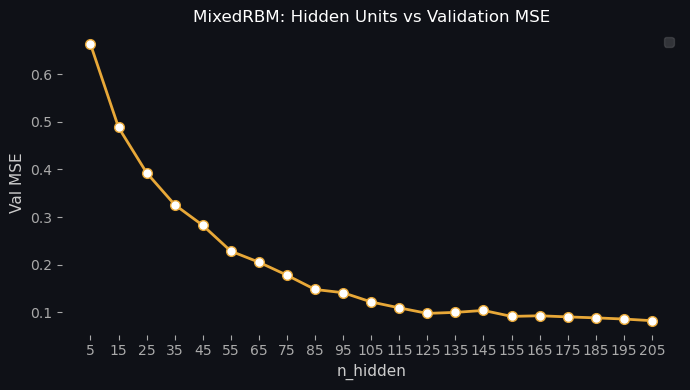

In [ ]:
n_vals   = [r['n_hidden'] for r in sweep_results]
val_vals = [r['best_val'] for r in sweep_results]
 
fig, ax = plt.subplots(figsize=(7, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(n_vals, val_vals, color='#e8a838', linewidth=2, marker='o',
        markersize=7, markerfacecolor='white', markeredgecolor='#e8a838')
ax.set_xlabel('n_hidden', color='#cccccc', fontsize=11)
ax.set_ylabel('Val MSE', color='#cccccc', fontsize=11)
ax.set_title('MixedRBM: Hidden Units vs Validation MSE', color='white', fontsize=12)
ax.set_xticks(n_vals)
ax.tick_params(colors='#aaaaaa')
ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

### KneeLocator

1. **Normalize** $n\_hiden$ and val MSE to $[0, 1]$
2. **Fit** a smooth curve through the points
3. **Compute** the difference between the curve and the straight line connecting the first and last points
4. The **knee** is where this difference is maximized

In [ ]:
kneedle = KneeLocator(n_vals, val_vals, curve="convex", direction="decreasing")
print(kneedle.elbow)

85


/var/folders/rq/k6q5m5x57ggcclsdrpv0g4j00000gn/T/ipykernel_38494/682612178.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc')


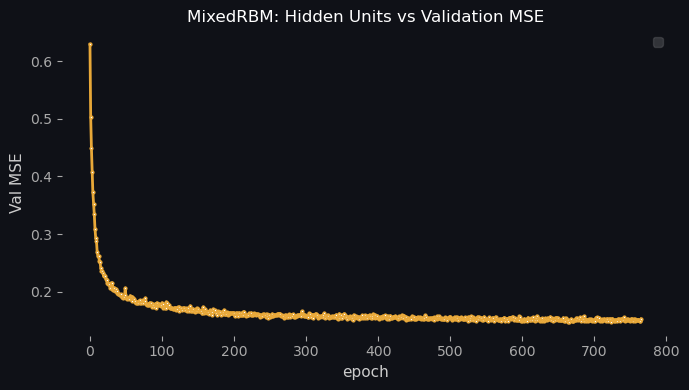

In [ ]:
r65 = next(r for r in sweep_results if r['n_hidden'] == 85)
fig, ax = plt.subplots(figsize=(7, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(range(r65['epochs']), r65['val_history'], color='#e8a838', linewidth=2, marker='o',
        markersize=2, markerfacecolor='white', markeredgecolor='#e8a838')
ax.set_xlabel('epoch', color='#cccccc', fontsize=11)
ax.set_ylabel('Val MSE', color='#cccccc', fontsize=11)
ax.set_title('MixedRBM: Hidden Units vs Validation MSE', color='white', fontsize=12)
ax.tick_params(colors='#aaaaaa')
ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

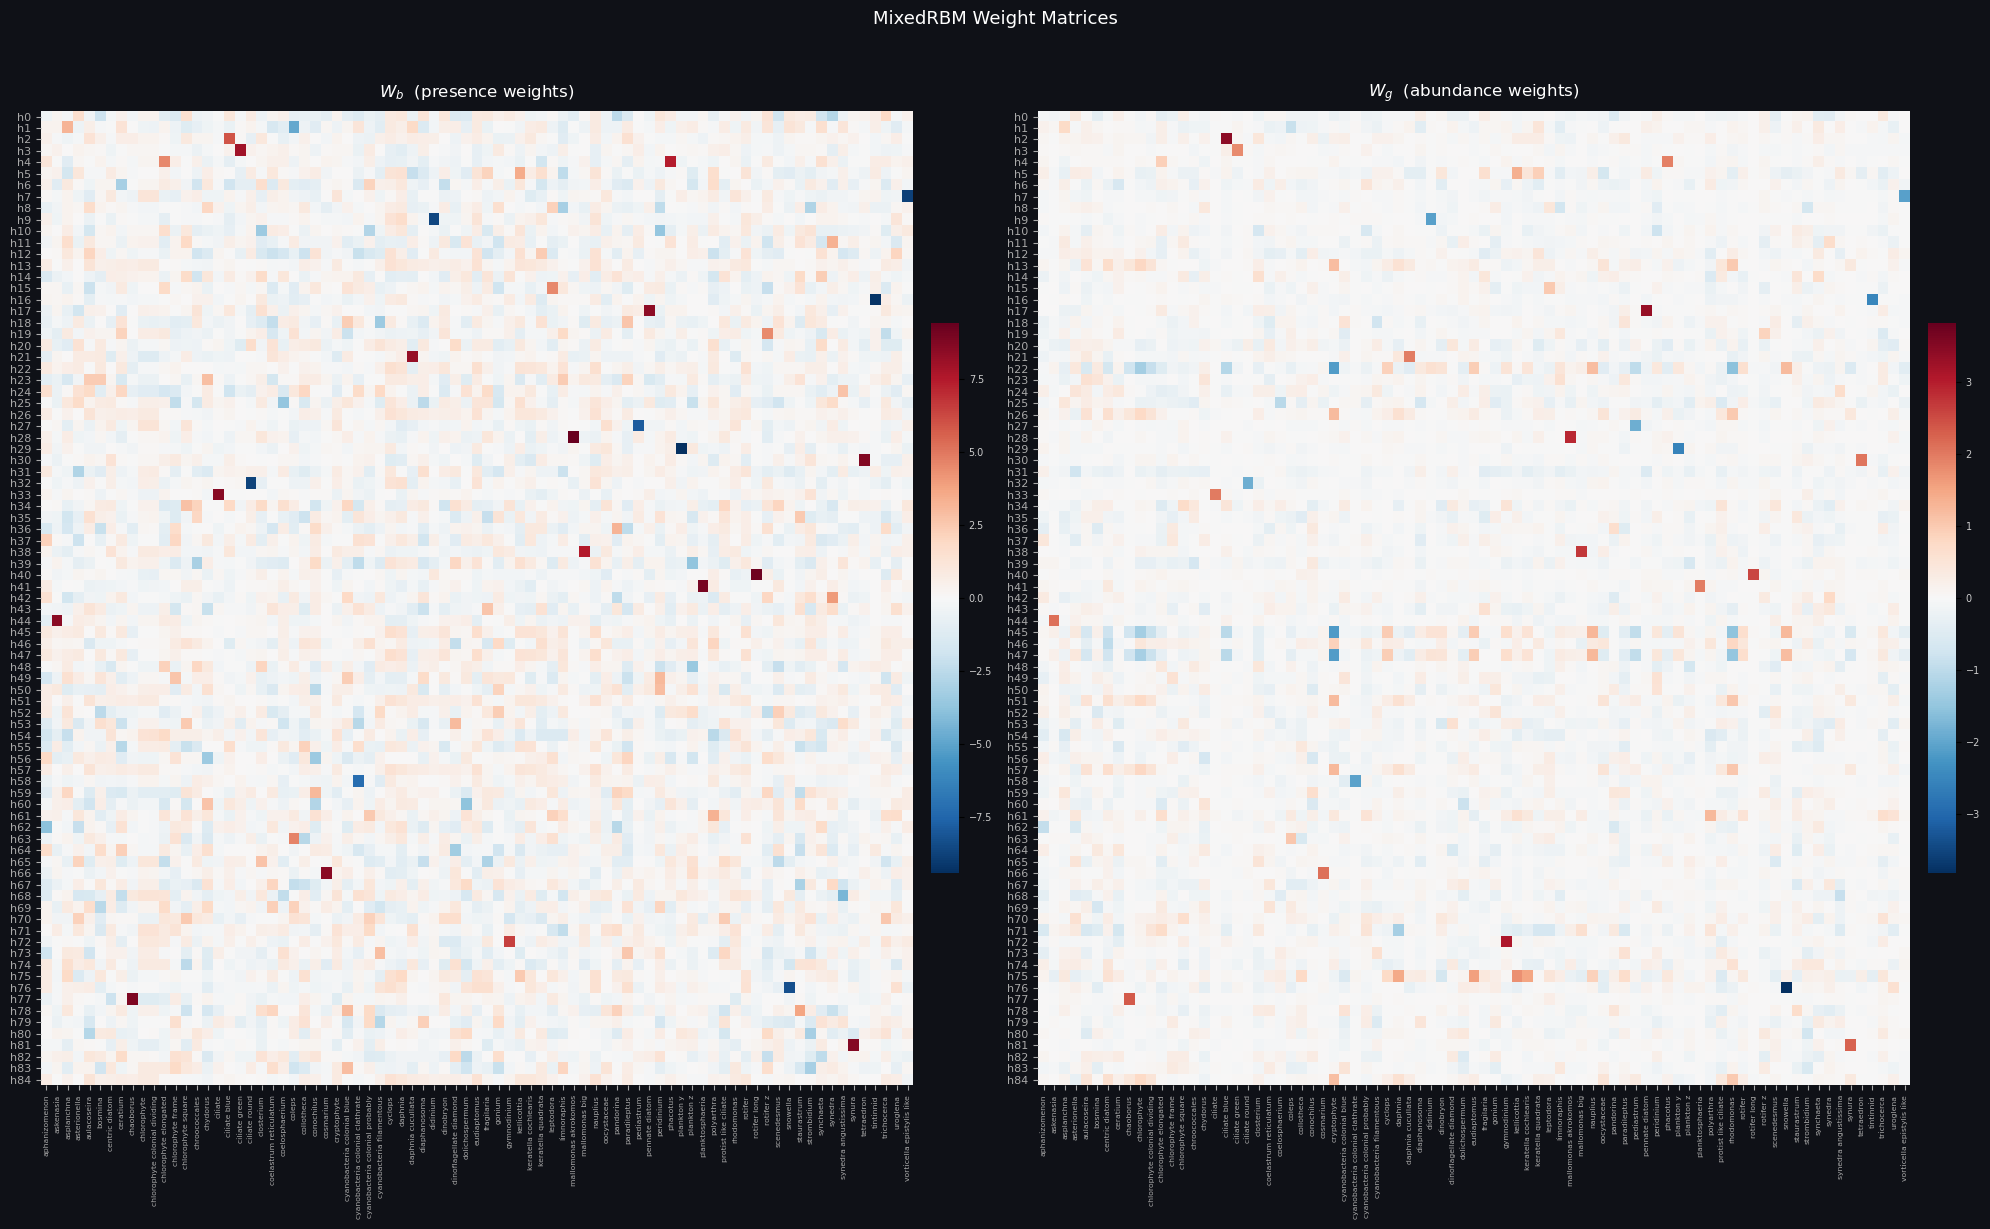

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 12), facecolor='#0f1117')
sp_labels = [s.replace('_', ' ') for s in species]
 
for ax, W, title in zip(axes,
                        [r65['snap']['Wb'], r65['snap']['Wg']],
                        ['$W_b$  (presence weights)', '$W_g$  (abundance weights)']):
    ax.set_facecolor('#0f1117')
    vmax = np.abs(W).max()
    im = ax.imshow(W, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(species)))
    ax.set_xticklabels(sp_labels, rotation=90, fontsize=5.5, color='#cccccc')
    ax.set_yticks(range(r65["n_hidden"]))
    ax.set_yticklabels([f'h{i}' for i in range(r65['n_hidden'])], fontsize=8, color='#cccccc')
    ax.set_title(title, color='white', fontsize=12, pad=10)
    cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cb.ax.yaxis.set_tick_params(labelsize=7)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
    cb.outline.set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#aaaaaa')
 
plt.suptitle('MixedRBM Weight Matrices', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

where:

- $a(i)$ = mean distance from point $i$ to all other points in its own cluster 
- $b(i)$ = mean distance from point $i$ to all points in the nearest other cluster

The overall silhouette score is the mean of $s(i)$ across all points.



Silhouette-optimal K = 2  |  Using K = 2

Ecological-state summary from RBM latent space:
State  Days  % total Dominant season  Mean total density                                                                                        Top enriched taxa
   S0  1058     51.2          Spring              0.0523                      dinoflagellate diamond, bosmina, aulacoseira, conochilus, synchaeta, centric diatom
   S1  1008     48.8          Summer              0.0665 chroococcales, coelosphaerium, dinobryon, plankton z, chlorophyte frame, cyanobacteria colonial probably


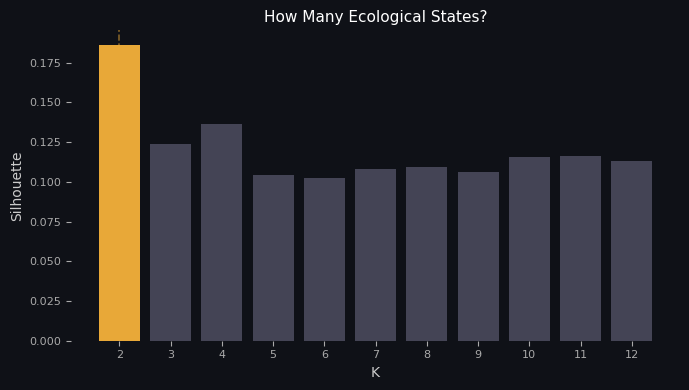

In [291]:
rbm65 = MixedRBM(n_vis, r65['n_hidden'])
#for k in ('Wb', 'Wg', 'bb', 'bg', 'bh'):
#    setattr(rbm65, k, r65['snap'][k])

H_both      = rbm65.encode(Vb, Vg)
H_presence  = np.stack([rbm65.h_given_v(Vb[t], np.zeros(n_vis, dtype=np.float32))
                        for t in range(T)])
H_abundance = np.stack([rbm65.h_given_v(np.zeros(n_vis, dtype=np.float32), Vg[t])
                        for t in range(T)])
H_list = [H_both]

X_real_log  = X_raw                                      # log10, not z-scored
rbm_species = species
dates_real  = pd.DatetimeIndex(dates)
months_real = np.array([d.month for d in dates_real])

season_map = {
    12: 'Winter',  1: 'Winter',  2: 'Winter',
     3: 'Spring',  4: 'Spring',  5: 'Spring',
     6: 'Summer',  7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}

RBM_K_RANGE = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

for H_real in H_list:
    sil_scores = []
    inertias = []
    for k in RBM_K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        lbl = km.fit_predict(H_real)
        sil_scores.append(silhouette_score(H_real, lbl))
        inertias.append(km.inertia_)

    auto_k   = list(RBM_K_RANGE)[int(np.argmax(sil_scores))]
    n_states = auto_k
    print(f'Silhouette-optimal K = {auto_k}  |  Using K = {n_states}')

    km_states = KMeans(n_clusters=n_states, random_state=42, n_init=20)
    rbm_state = km_states.fit_predict(H_real)
    state_H   = np.stack([H_real[rbm_state == k].mean(0) for k in range(n_states)])
    state_log = np.stack([X_real_log[rbm_state == k].mean(0) for k in range(n_states)])
    state_diff = state_log - X_real_log.mean(axis=0, keepdims=True)
    state_total = np.array([real_den[rbm_state == k].sum(axis=1).mean() for k in range(n_states)])

    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    seasons_real = np.array([season_map[m] for m in months_real])
    state_season = np.zeros((n_states, len(season_order)), dtype=float)
    summary_rows = []
    for k in range(n_states):
        mask = rbm_state == k
        for i, s in enumerate(season_order):
            state_season[k, i] = 100 * np.mean(seasons_real[mask] == s)
        dom_season = season_order[int(np.argmax(state_season[k]))]
        top_idx = np.argsort(state_diff[k])[-6:][::-1]
        summary_rows.append({
            'State': f'S{k}',
            'Days': int(mask.sum()),
            '% total': round(100 * mask.sum() / len(rbm_state), 1),
            'Dominant season': dom_season,
            'Mean total density': round(float(state_total[k]), 4),
            'Top enriched taxa': ', '.join(rbm_species[i].replace('_', ' ') for i in top_idx),
        })

    state_df = pd.DataFrame(summary_rows)
    print('\nEcological-state summary from RBM latent space:')
    print(state_df.to_string(index=False))

    species_idx = []
    for k in range(n_states):
        species_idx.extend(np.argsort(state_diff[k])[-5:][::-1].tolist())
    species_idx = list(dict.fromkeys(species_idx))
    dom_state   = np.argmax(state_diff[:, species_idx], axis=0)
    dom_score   = state_diff[:, species_idx][dom_state, np.arange(len(species_idx))]
    order       = np.lexsort((-dom_score, dom_state))
    species_idx = [species_idx[i] for i in order]
    species_lab = [rbm_species[i].replace('_', ' ') for i in species_idx]

    PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))
    fig, ax0 = plt.subplots(figsize=(7, 4), facecolor='#0f1117')
    ax0.set_facecolor('#0f1117')

    bar_colors = ['#e8a838' if k == n_states else '#444455' for k in RBM_K_RANGE]
    ax0.bar(list(RBM_K_RANGE), sil_scores, color=bar_colors, edgecolor='none')
    ax0.axvline(n_states, color='#e8a83888', linestyle='--', linewidth=1.2)
    ax0.set_xlabel('K', color='#cccccc')
    ax0.set_ylabel('Silhouette', color='#cccccc')
    ax0.set_title('How Many Ecological States?', color='white', fontsize=11)
    ax0.set_xticks(list(RBM_K_RANGE))
    ax0.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax0.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


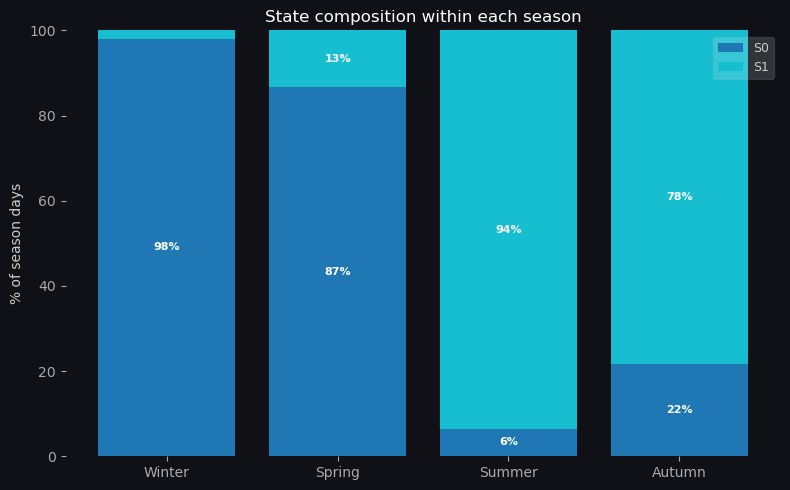

In [292]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))

# compute: for each season, % of its days in each state
season_state = np.zeros((len(season_order), n_states), dtype=float)
for i, s in enumerate(season_order):
    season_mask = seasons_real == s
    for k in range(n_states):
        season_state[i, k] = 100 * np.mean((rbm_state == k)[season_mask])

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

bottom = np.zeros(len(season_order))
for k in range(n_states):
    vals = season_state[:, k]
    ax.bar(season_order, vals, bottom=bottom,
           color=PAL[k], label=f'S{k}', edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 6:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('% of season days', color='#cccccc', fontsize=10)
ax.set_title('State composition within each season', color='white', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.15, labelcolor='#cccccc')
ax.tick_params(colors='#aaaaaa')
ax.set_ylim(0, 100)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

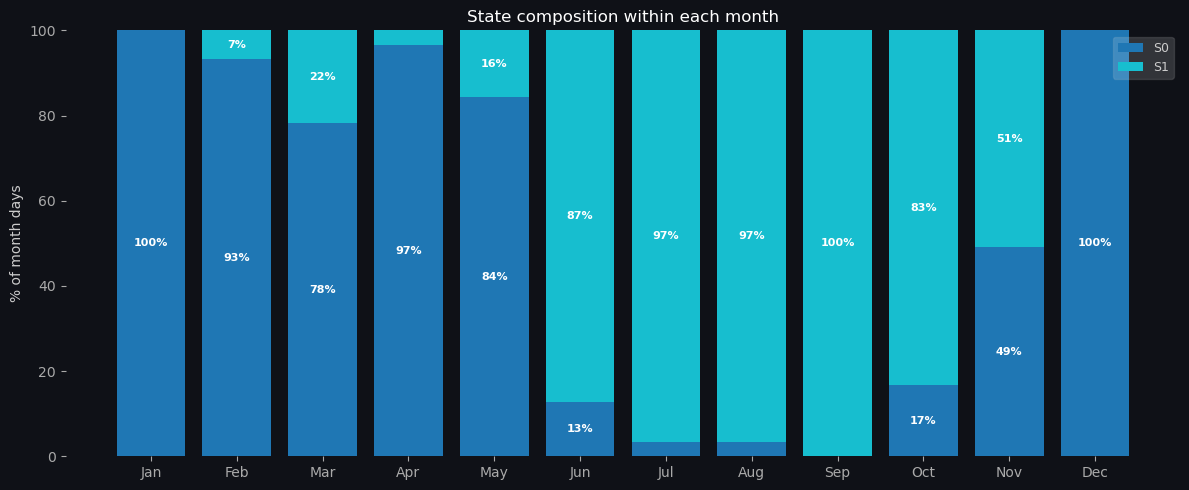

In [293]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
months_real = np.array([d.month for d in dates_real])

# for each month, % of its days in each state
month_state = np.zeros((12, n_states), dtype=float)
for i, m in enumerate(range(1, 13)):
    month_mask = months_real == m
    for k in range(n_states):
        month_state[i, k] = 100 * np.mean((rbm_state == k)[month_mask])

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

bottom = np.zeros(12)
for k in range(n_states):
    vals = month_state[:, k]
    ax.bar(month_names, vals, bottom=bottom,
           color=PAL[k], label=f'S{k}', edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 6:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('% of month days', color='#cccccc', fontsize=10)
ax.set_title('State composition within each month', color='white', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.15, labelcolor='#cccccc')
ax.tick_params(colors='#aaaaaa')
ax.set_ylim(0, 100)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

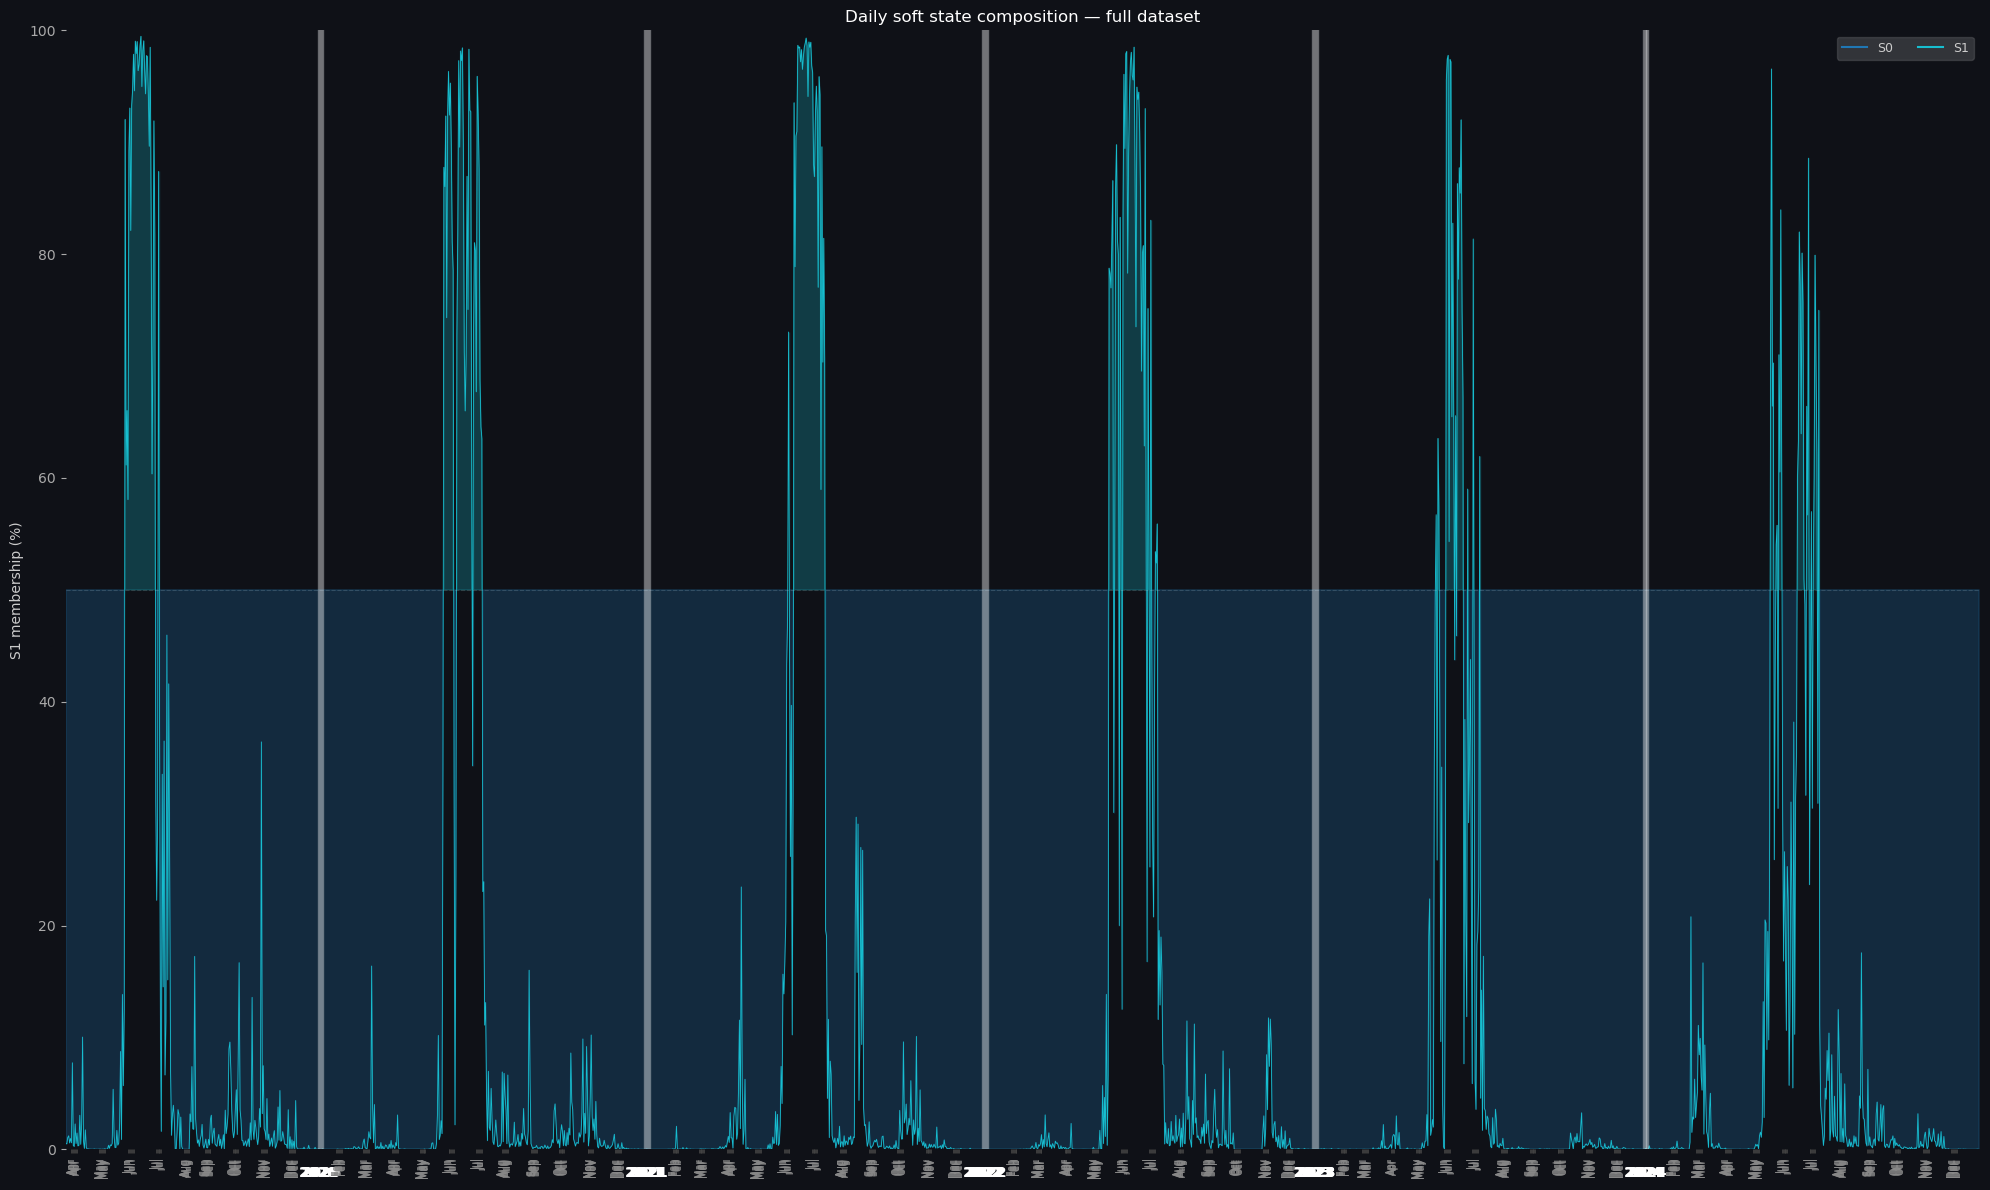

In [302]:
dists       = km.transform(H_both)
temperature = 0.1
soft_probs  = softmax(-dists / (dists.std() * temperature), axis=1)

day_idx = np.arange(len(dates_real))

fig, ax = plt.subplots(figsize=(20, 12), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

ax.plot(day_idx, 100 * soft_probs[:, 1], color=PAL[1], linewidth=0.6)
ax.axhline(50, color='#ffffff22', linewidth=0.8, linestyle='--')
ax.fill_between(day_idx, 50, 100 * soft_probs[:, 1],
                where=(soft_probs[:, 1] > 0.5), color=PAL[1], alpha=0.25)
ax.fill_between(day_idx, 100 * soft_probs[:, 1], 50,
                where=(soft_probs[:, 1] < 0.5), color=PAL[0], alpha=0.25)

# ── Year lines + labels ───────────────────────────────────────────────────────
jan_pos = [i for i, d in enumerate(dates_real) if d.month == 1 and d.day <= 7]
for xi in jan_pos:
    ax.axvline(xi, color='#ffffff55', linewidth=1.0)
ax.set_xticks(jan_pos)
ax.set_xticklabels([str(dates_real[i].year) for i in jan_pos],
                   color='white', fontsize=10, fontweight='bold')

# ── Month tick marks + labels ─────────────────────────────────────────────────
mon_pos = [i for i, d in enumerate(dates_real) if d.day <= 7 and d.month != 1]
mon_lbl = [dates_real[i].strftime('%b') for i in mon_pos]
ax.set_xticks(mon_pos, minor=True)
ax.set_xticklabels(mon_lbl, minor=True, color='#888888', fontsize=7, rotation=90)
ax.tick_params(axis='x', which='minor', length=3, color='#444444')
ax.tick_params(axis='x', which='major', length=0, pad=12)

ax.set_ylabel('S1 membership (%)', color='#cccccc', fontsize=10)
ax.set_title('Daily soft state composition — full dataset', color='white', fontsize=12)
ax.legend(handles=[plt.Line2D([0],[0], color=PAL[k], label=f'S{k}') for k in range(n_states)],
          fontsize=9, framealpha=0.15, labelcolor='#cccccc', ncol=n_states)
ax.set_ylim(0, 100)
ax.set_xlim(0, len(dates_real))
ax.tick_params(axis='y', colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

Silhouette-optimal K = 4  |  Using K = 4


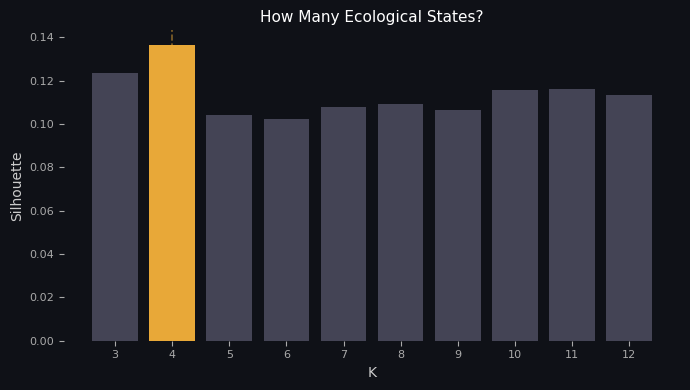

In [353]:
rbm65 = MixedRBM(n_vis, r65['n_hidden'])
#for k in ('Wb', 'Wg', 'bb', 'bg', 'bh'):
#    setattr(rbm65, k, r65['snap'][k])

H_both      = rbm65.encode(Vb, Vg)
H_presence  = np.stack([rbm65.h_given_v(Vb[t], np.zeros(n_vis, dtype=np.float32))
                        for t in range(T)])
H_abundance = np.stack([rbm65.h_given_v(np.zeros(n_vis, dtype=np.float32), Vg[t])
                        for t in range(T)])
H_list = [H_both]

X_real_log  = X_raw                                      # log10, not z-scored
rbm_species = species
dates_real  = pd.DatetimeIndex(dates)
months_real = np.array([d.month for d in dates_real])

season_map = {
    12: 'Winter',  1: 'Winter',  2: 'Winter',
     3: 'Spring',  4: 'Spring',  5: 'Spring',
     6: 'Summer',  7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}

RBM_K_RANGE = [3,4, 5, 6, 7, 8, 9, 10, 11, 12]

for H_real in H_list:
    sil_scores = []
    inertias = []
    for k in RBM_K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        lbl = km.fit_predict(H_real)
        sil_scores.append(silhouette_score(H_real, lbl))
        inertias.append(km.inertia_)

    auto_k   = list(RBM_K_RANGE)[int(np.argmax(sil_scores))]
    n_states = auto_k
    print(f'Silhouette-optimal K = {auto_k}  |  Using K = {n_states}')

    km_states = KMeans(n_clusters=n_states, random_state=42, n_init=20)
    rbm_state = km_states.fit_predict(H_real)
    state_H   = np.stack([H_real[rbm_state == k].mean(0) for k in range(n_states)])
    state_log = np.stack([X_real_log[rbm_state == k].mean(0) for k in range(n_states)])
    state_diff = state_log - X_real_log.mean(axis=0, keepdims=True)
    state_total = np.array([real_den[rbm_state == k].sum(axis=1).mean() for k in range(n_states)])

    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    seasons_real = np.array([season_map[m] for m in months_real])
    state_season = np.zeros((n_states, len(season_order)), dtype=float)
    summary_rows = []
    for k in range(n_states):
        mask = rbm_state == k
        for i, s in enumerate(season_order):
            state_season[k, i] = 100 * np.mean(seasons_real[mask] == s)
        dom_season = season_order[int(np.argmax(state_season[k]))]
        top_idx = np.argsort(state_diff[k])[-6:][::-1]
        summary_rows.append({
            'State': f'S{k}',
            'Days': int(mask.sum()),
            '% total': round(100 * mask.sum() / len(rbm_state), 1),
            'Dominant season': dom_season,
            'Mean total density': round(float(state_total[k]), 4),
            'Top enriched taxa': ', '.join(rbm_species[i].replace('_', ' ') for i in top_idx),
        })

    state_df = pd.DataFrame(summary_rows)

    species_idx = []
    for k in range(n_states):
        species_idx.extend(np.argsort(state_diff[k])[-5:][::-1].tolist())
    species_idx = list(dict.fromkeys(species_idx))
    dom_state   = np.argmax(state_diff[:, species_idx], axis=0)
    dom_score   = state_diff[:, species_idx][dom_state, np.arange(len(species_idx))]
    order       = np.lexsort((-dom_score, dom_state))
    species_idx = [species_idx[i] for i in order]
    species_lab = [rbm_species[i].replace('_', ' ') for i in species_idx]

    PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))
    fig, ax0 = plt.subplots(figsize=(7, 4), facecolor='#0f1117')
    ax0.set_facecolor('#0f1117')

    bar_colors = ['#e8a838' if k == n_states else '#444455' for k in RBM_K_RANGE]
    ax0.bar(list(RBM_K_RANGE), sil_scores, color=bar_colors, edgecolor='none')
    ax0.axvline(n_states, color='#e8a83888', linestyle='--', linewidth=1.2)
    ax0.set_xlabel('K', color='#cccccc')
    ax0.set_ylabel('Silhouette', color='#cccccc')
    ax0.set_title('How Many Ecological States?', color='white', fontsize=11)
    ax0.set_xticks(list(RBM_K_RANGE))
    ax0.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax0.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

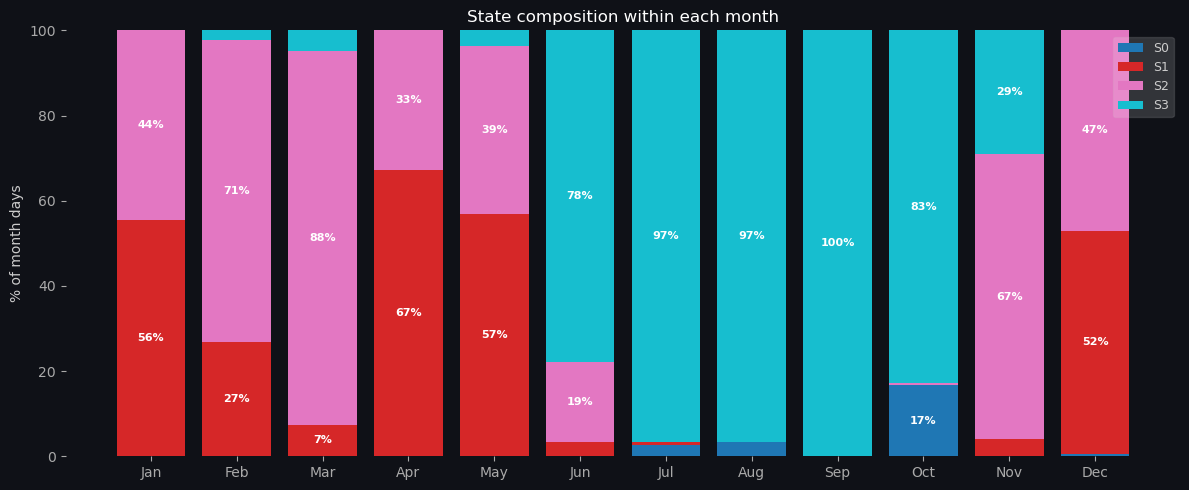

   Season  S0 (%)  S1 (%)  S2 (%)  S3 (%)
0     Jan     0.0    55.6    44.4     0.0
1     Feb     0.0    26.9    70.9     2.2
2     Mar     0.0     7.5    87.6     5.0
3     Apr     0.0    67.2    32.8     0.0
4     May     0.0    57.0    39.2     3.8
5     Jun     0.0     3.3    18.9    77.8
6     Jul     2.7     0.5     0.0    96.7
7     Aug     3.4     0.0     0.0    96.6
8     Sep     0.0     0.0     0.0   100.0
9     Oct    16.7     0.0     0.5    82.8
10    Nov     0.0     4.0    66.9    29.1
11    Dec     0.5    52.5    47.0     0.0


In [360]:
PAL = plt.cm.tab10(np.linspace(0, 0.9, n_states))
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
months_real = np.array([d.month for d in dates_real])

# for each month, % of its days in each state
month_state = np.zeros((12, n_states), dtype=float)
rows = []
for i, m in enumerate(range(1, 13)):
    month_mask = months_real == m
    for k in range(n_states):
        month_state[i, k] = 100 * np.mean((rbm_state == k)[month_mask])

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

bottom = np.zeros(12)
for k in range(n_states):
    vals = month_state[:, k]
    ax.bar(month_names, vals, bottom=bottom,
           color=PAL[k], label=f'S{k}', edgecolor='none')
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 6:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('% of month days', color='#cccccc', fontsize=10)
ax.set_title('State composition within each month', color='white', fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.15, labelcolor='#cccccc')
ax.tick_params(colors='#aaaaaa')
ax.set_ylim(0, 100)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()
for i, s in enumerate(month_names):
    row = {'Season': s}
    for k in range(n_states):
        row[f'S{k} (%)'] = round(month_state[i, k], 1)
    rows.append(row)
 
month_table = pd.DataFrame(rows)
print(month_table.to_string())

## Ecological State Interpretation

### S0 — Late-season cyanobacteria bloom (Jul–Aug minor, Oct major)
- Highest enrichment values of all states for colonial cyanobacteria:
  *coelosphaerium* (Δ=+1.92), *cyanobacteria_colonial_clathrate* (Δ=+1.79), *chroococcales* (Δ=+1.49)
- Appears in late summer/autumn — consistent with cyanobacteria blooms peaking after prolonged thermal stratification
- October 2022 is 100% S0: *aulacoseira* completely absent (0.0000 vs overall 0.0184), colonial cyanobacteria elevated 2–8×
- A **rare state** (~2% of all days), requiring anomalously warm autumns to sustain stratification beyond the typical mixing season
- October 2022 was the warmest October ever recorded in Switzerland since national records began in 1864. The country experienced an average temperature of 10.4° C.
- In August 2020, Switzerland experienced a notably warm and sunny month. Nationwide average temperatures across the country were roughly 1.5°C to 2.0°C warmer than usual compared to the standard long-term norms.

### S1 - Transitional Assamblege

### S3 — General warm season (Jun–Oct)
- Enriched in the same taxa as S0 but at lower Δ values (*coelosphaerium* +1.55 vs +1.92)
- The broad summer/stratified lake regime; **S0 is its more extreme cyanobacteria-dominated version**
- September is the purest state in the dataset — 100% S3

### S2 — Winter diatom bloom (Feb–Mar dominant, Nov)
- *aulacoseira* (Δ=+0.92) and *synedra_angustissima* (Δ=+0.49) confirm a **deep-mixing diatom regime**
- *dinoflagellate_diamond* shows the highest Δ of any state (Δ=+1.27) — co-blooming with diatoms in late winter
- Peaks in **March (88%)** — the height of the winter mixing / diatom bloom phase

In [362]:
for k in range(n_states):
    top_idx = np.argsort(state_diff[k])[-6:][::-1]
    print(f"\nS{k} — top enriched taxa:")
    for i in top_idx:
        print(f"  {species[i]:<40s}  Δ={state_diff[k, i]:+.4f}")


S0 — top enriched taxa:
  coelosphaerium                            Δ=+1.9243
  cyanobacteria_colonial_clathrate          Δ=+1.7850
  coelastrum_reticulatum                    Δ=+1.6951
  plankton_z                                Δ=+1.6848
  cyanobacteria_colonial_probably           Δ=+1.5343
  chroococcales                             Δ=+1.4880

S1 — top enriched taxa:
  dinoflagellate_diamond                    Δ=+0.5853
  bosmina                                   Δ=+0.5550
  asplanchna                                Δ=+0.2002
  ciliate                                   Δ=+0.1948
  conochilus                                Δ=+0.1844
  kellicottia                               Δ=+0.1270

S2 — top enriched taxa:
  dinoflagellate_diamond                    Δ=+1.2680
  aulacoseira                               Δ=+0.9156
  ciliate_round                             Δ=+0.7641
  synedra_angustissima                      Δ=+0.4881
  synchaeta                                 Δ=+0.4458
  tinti

In [361]:
dates_idx = pd.DatetimeIndex(dates_real)
oct22_mask = (dates_idx.year == 2022) & (dates_idx.month == 10)

print(f"Oct 2022 days: {oct22_mask.sum()}")
print(f"States assigned: {np.unique(rbm_state[oct22_mask], return_counts=True)}")

aulacoseira_idx = list(species).index('aulacoseira')
print(f"\nAulacoseira mean density in Oct 2022 : {real_den[oct22_mask, aulacoseira_idx].mean():.4f}")
print(f"Aulacoseira mean density overall     : {real_den[:, aulacoseira_idx].mean():.4f}")
print(f"Aulacoseira zero days in Oct 2022    : {(real_den[oct22_mask, aulacoseira_idx] == 0).sum()} / {oct22_mask.sum()}")

cyano_taxa = [i for i, s in enumerate(species) if 'cyano' in s or 'coelosphaerium' in s or 'chroococcales' in s]
print(f"\nCyanobacteria taxa checked: {[species[i] for i in cyano_taxa]}")
for i in cyano_taxa:
    mean_oct = real_den[oct22_mask, i].mean()
    mean_all = real_den[:, i].mean()
    print(f"  {species[i]:<45s}  Oct2022={mean_oct:.4f}  overall={mean_all:.4f}  ratio={mean_oct/(mean_all+1e-8):.1f}x")

Oct 2022 days: 31
States assigned: (array([0], dtype=int32), array([31]))

Aulacoseira mean density in Oct 2022 : 0.0000
Aulacoseira mean density overall     : 0.0184
Aulacoseira zero days in Oct 2022    : 31 / 31

Cyanobacteria taxa checked: ['chroococcales', 'coelosphaerium', 'cyanobacteria_colonial_blue', 'cyanobacteria_colonial_clathrate', 'cyanobacteria_colonial_probably', 'cyanobacteria_filamentous']
  chroococcales                                  Oct2022=0.0028  overall=0.0006  ratio=4.3x
  coelosphaerium                                 Oct2022=0.0003  overall=0.0002  ratio=1.6x
  cyanobacteria_colonial_blue                    Oct2022=0.0014  overall=0.0006  ratio=2.2x
  cyanobacteria_colonial_clathrate               Oct2022=0.0002  overall=0.0000  ratio=8.4x
  cyanobacteria_colonial_probably                Oct2022=0.0059  overall=0.0015  ratio=4.0x
  cyanobacteria_filamentous                      Oct2022=0.0000  overall=0.0004  ratio=0.0x


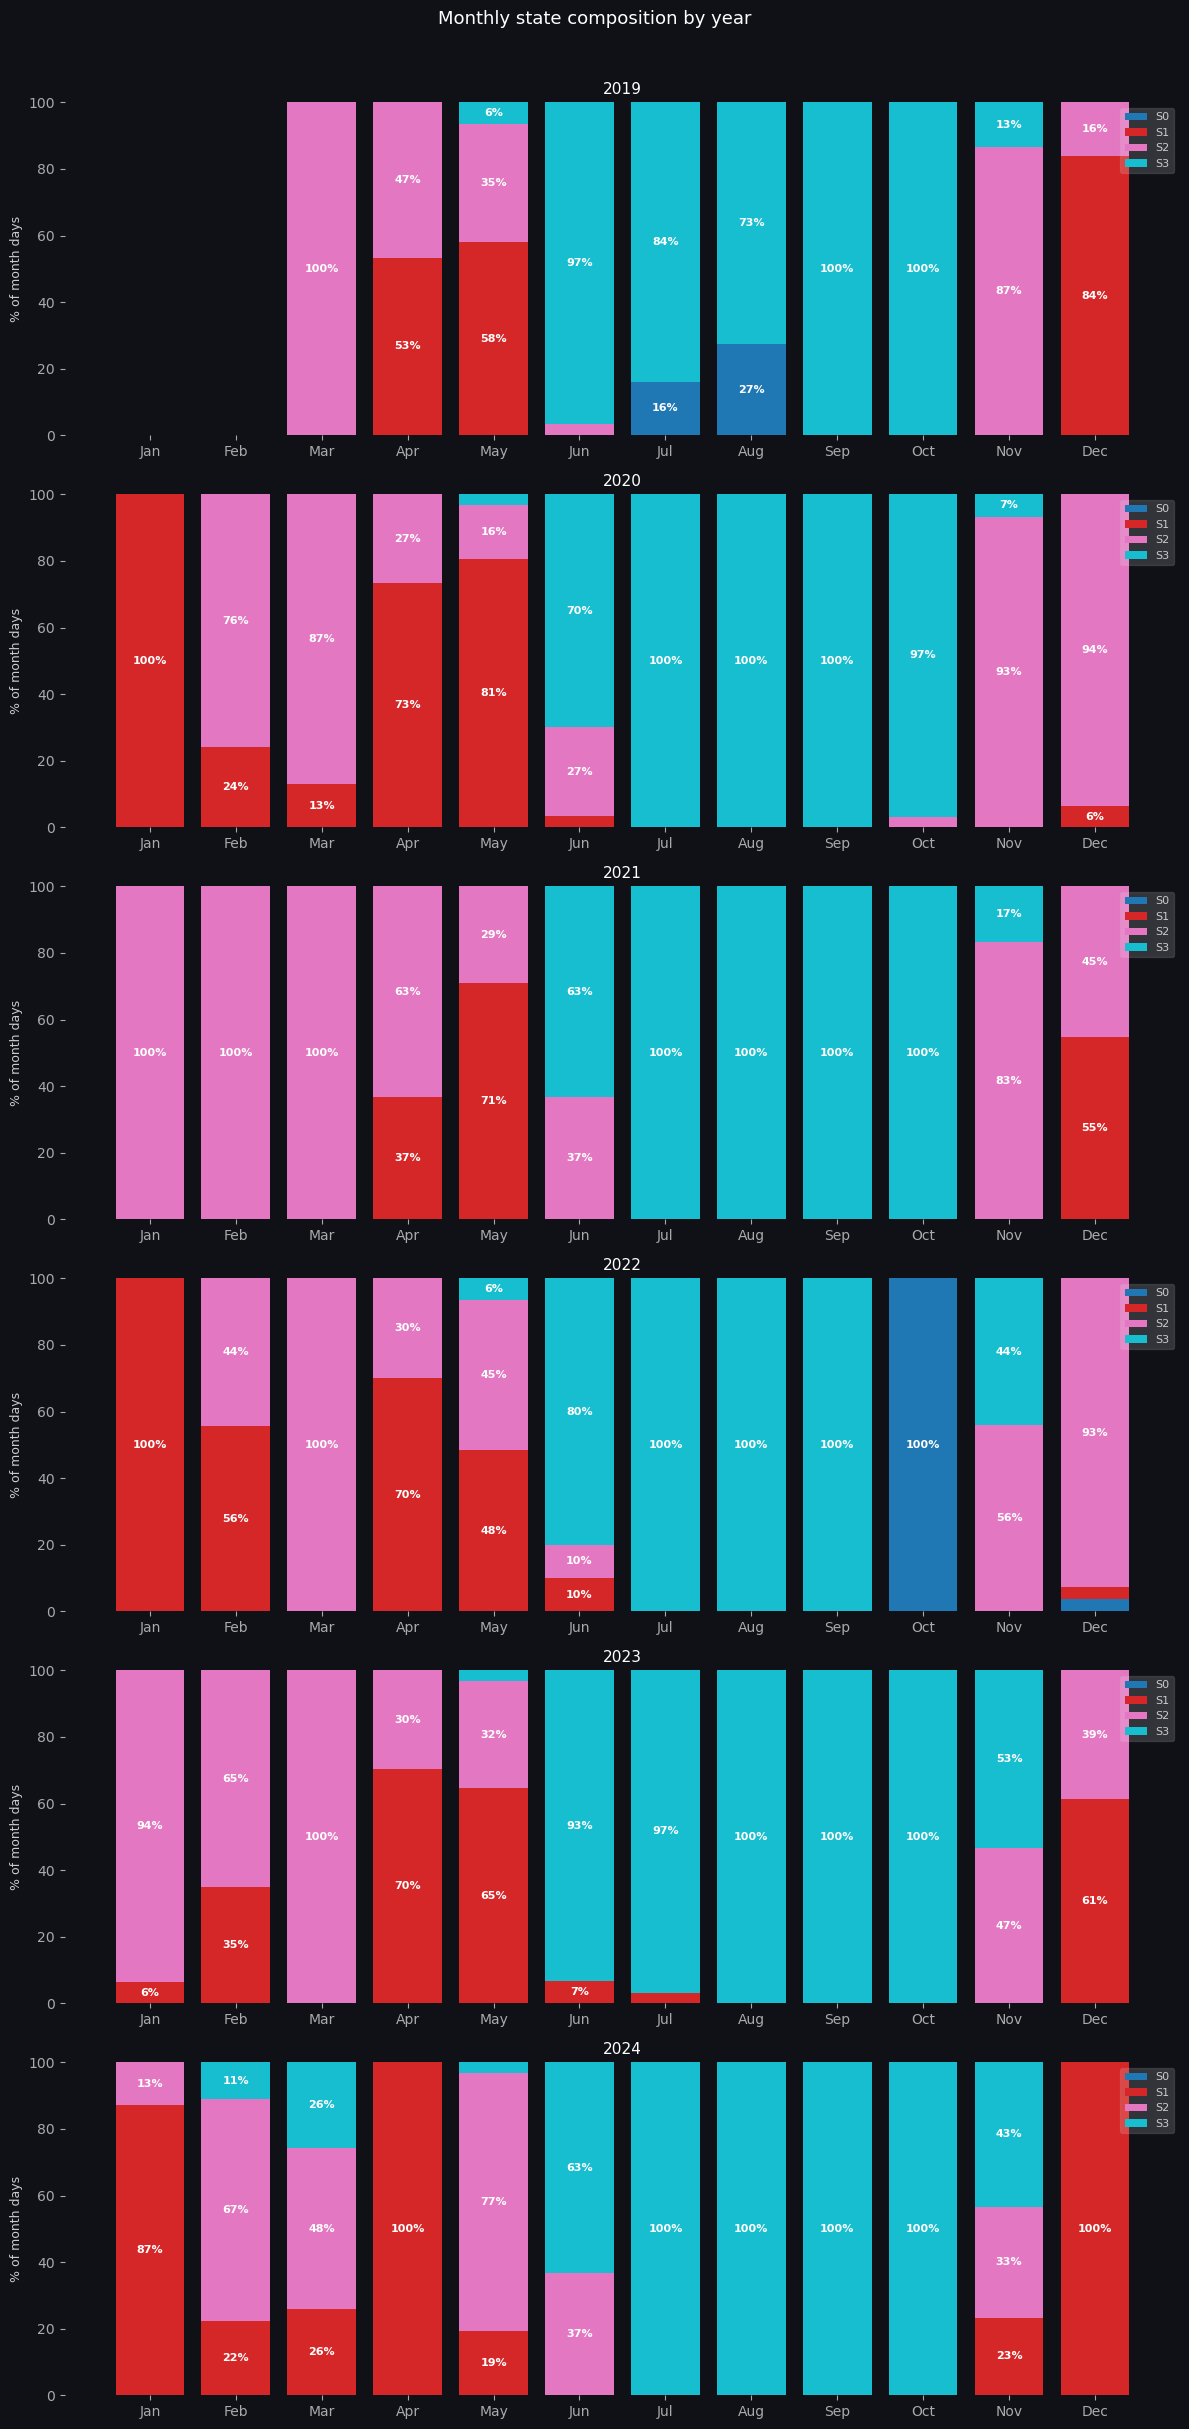

In [347]:
years = sorted(set(d.year for d in dates_real))

fig, axes = plt.subplots(len(years), 1, figsize=(12, 4 * len(years)), facecolor='#0f1117')
if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    ax.set_facecolor('#0f1117')
    year_mask = np.array([d.year == year for d in dates_real])

    month_state_yr = np.zeros((12, n_states), dtype=float)
    for i, m in enumerate(range(1, 13)):
        month_mask = year_mask & (months_real == m)
        if month_mask.sum() == 0:
            continue
        for k in range(n_states):
            month_state_yr[i, k] = 100 * np.mean((rbm_state == k)[month_mask])

    bottom = np.zeros(12)
    for k in range(n_states):
        vals = month_state_yr[:, k]
        ax.bar(month_names, vals, bottom=bottom,
               color=PAL[k], label=f'S{k}', edgecolor='none')
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 6:
                ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += vals

    ax.set_ylabel('% of month days', color='#cccccc', fontsize=9)
    ax.set_title(str(year), color='white', fontsize=11)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.15, labelcolor='#cccccc')
    ax.tick_params(colors='#aaaaaa')
    ax.set_ylim(0, 100)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('Monthly state composition by year', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

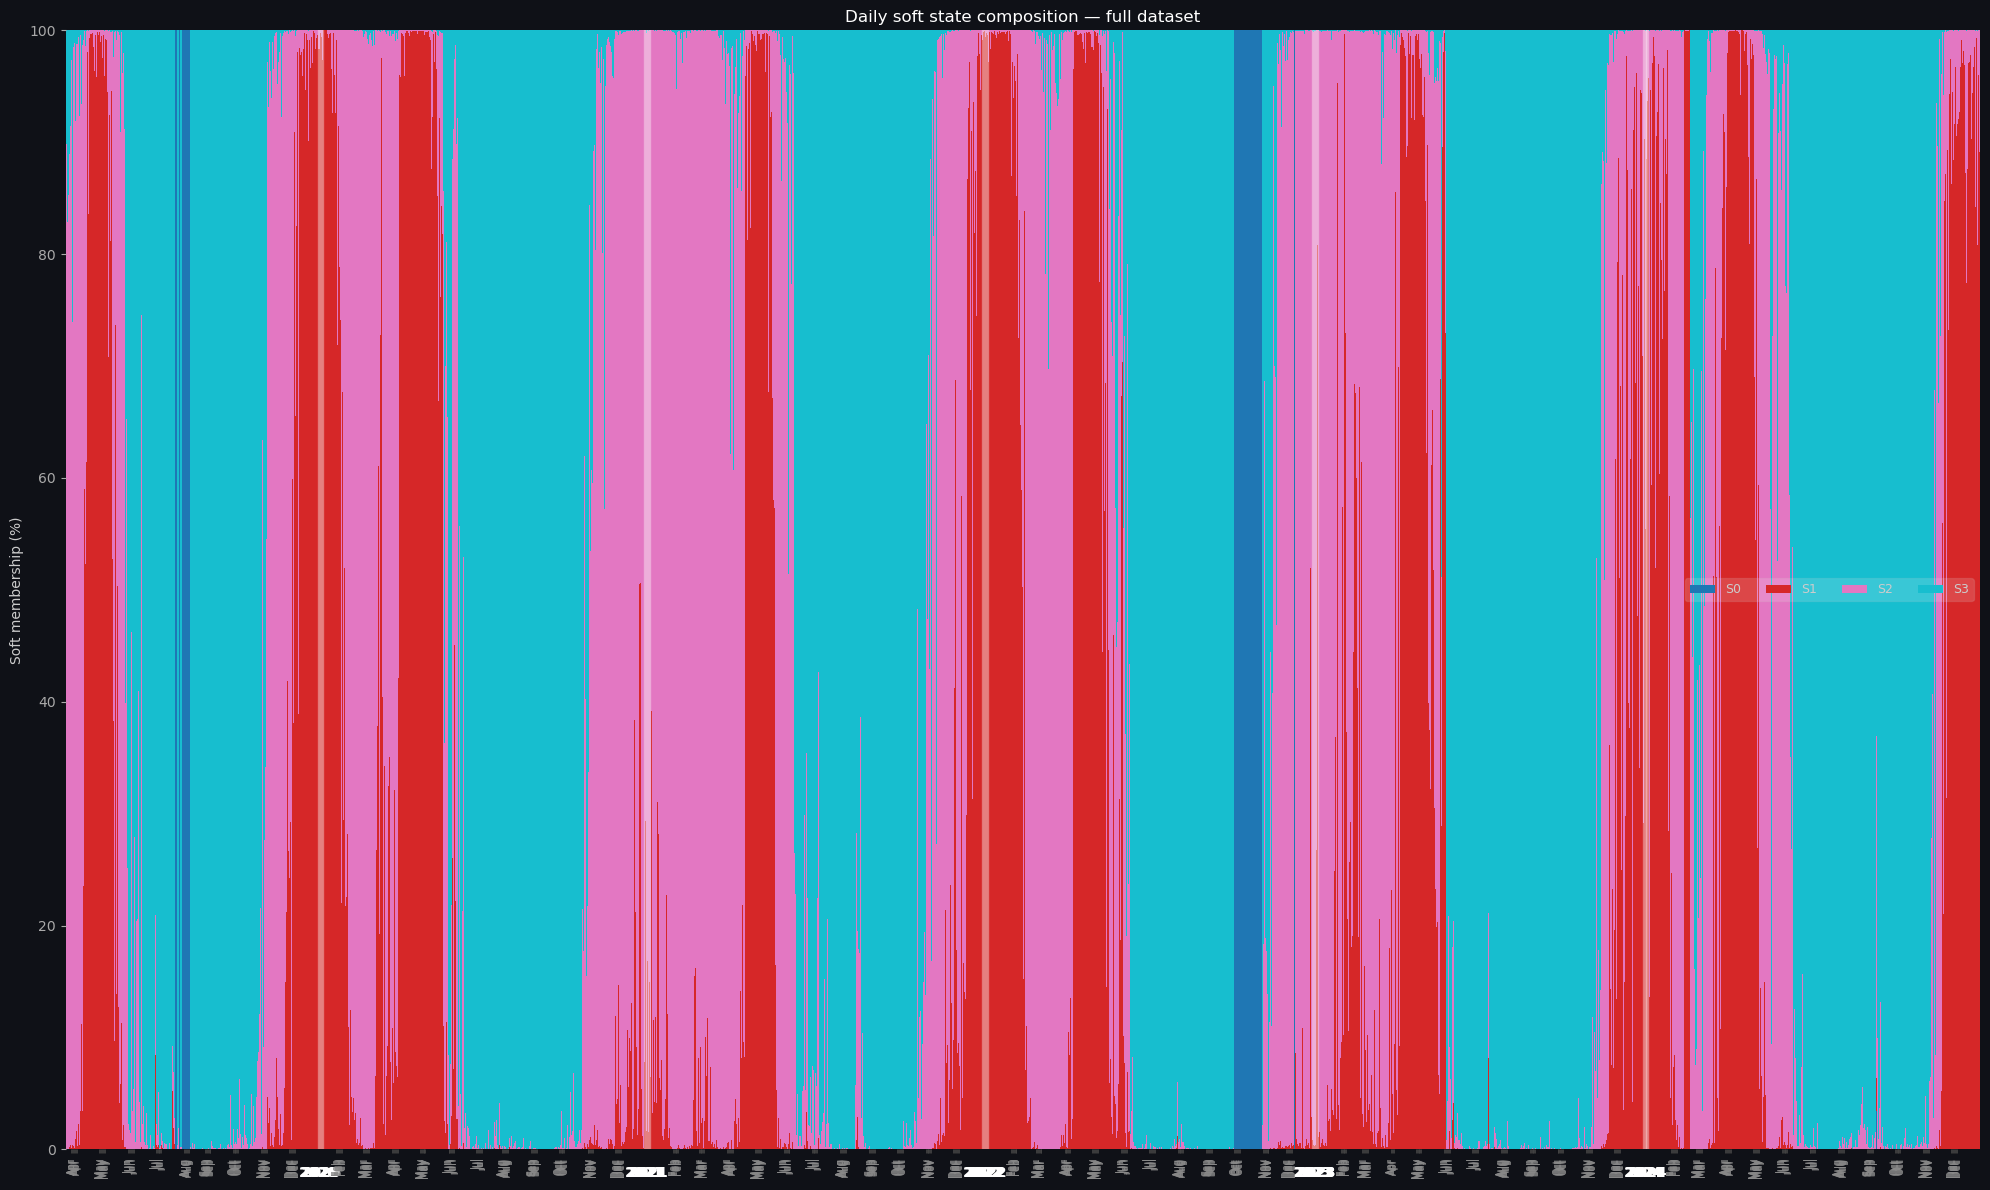

In [338]:
dists       = km_states.transform(H_both)
temperature = 0.1
soft_probs  = softmax(-dists / (dists.std() * temperature), axis=1)
 
fig, ax = plt.subplots(figsize=(20, 12), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
 
day_idx = np.arange(len(dates_real))
bottom  = np.zeros(len(dates_real))
 
for k in range(n_states):
    vals = 100 * soft_probs[:, k]
    ax.bar(day_idx, vals, bottom=bottom, color=PAL[k],
           label=f'S{k}', edgecolor='none', width=1.0)
    bottom += vals
 
# ── Year lines + labels ───────────────────────────────────────────────────────
jan_pos = [i for i, d in enumerate(dates_real) if d.month == 1 and d.day <= 7]
for xi in jan_pos:
    ax.axvline(xi, color='#ffffff55', linewidth=1.0)
ax.set_xticks(jan_pos)
ax.set_xticklabels([str(dates_real[i].year) for i in jan_pos],
                   color='white', fontsize=10, fontweight='bold')
 
# ── Month tick marks + labels ─────────────────────────────────────────────────
mon_pos = [i for i, d in enumerate(dates_real) if d.day <= 7 and d.month != 1]
mon_lbl = [dates_real[i].strftime('%b') for i in mon_pos]
ax.set_xticks(mon_pos, minor=True)
ax.set_xticklabels(mon_lbl, minor=True, color='#888888', fontsize=7, rotation=90)
ax.tick_params(axis='x', which='minor', length=3, color='#444444')
ax.tick_params(axis='x', which='major', length=0, pad=12)
 
ax.set_ylabel('Soft membership (%)', color='#cccccc', fontsize=10)
ax.set_title('Daily soft state composition — full dataset', color='white', fontsize=12)
ax.legend(fontsize=9, framealpha=0.15, labelcolor='#cccccc', ncol=n_states)
ax.set_ylim(0, 100)
ax.set_xlim(0, len(dates_real))
ax.tick_params(axis='y', colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

In [311]:
target_state = 0   

s3_dates = dates_real[rbm_state == target_state]

intervals = []
start = s3_dates[0]
prev  = s3_dates[0]

for d in s3_dates[1:]:
    if (d - prev).days > 7:
        intervals.append((start, prev))
        start = d
    prev = d
intervals.append((start, prev))

print(f"S{target_state} dominant intervals ({len(intervals)} periods):\n")
for i, (s, e) in enumerate(intervals):
    n_days = (rbm_state == target_state)[(dates_real >= s) & (dates_real <= e)].sum()
    print(f"  [{i+1:2d}]  {s.date()}  →  {e.date()}   ({n_days} days)")

S0 dominant intervals (3 periods):

  [ 1]  2019-07-22  →  2019-08-06   (11 days)
  [ 2]  2022-10-01  →  2022-10-31   (31 days)
  [ 3]  2022-12-10  →  2022-12-10   (1 days)


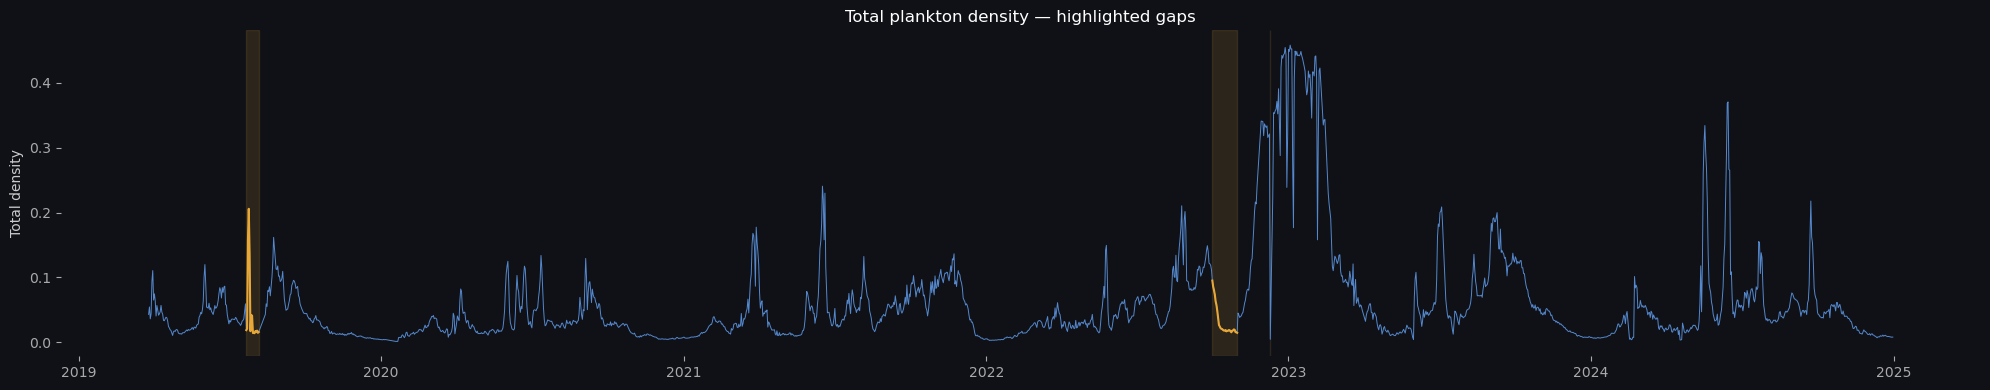

In [357]:
dates_idx     = pd.DatetimeIndex(dates)
total_density = real_den.sum(axis=1)
 
gap_ranges = [
    ('2019-07-22', '2019-08-06'),
    ('2022-10-01', '2022-10-31'),
    ('2022-12-10', '2022-12-10'),
]
 
fig, ax = plt.subplots(figsize=(20, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
 
ax.plot(dates_idx, total_density, color='#5588cc', linewidth=0.7, zorder=1)
 
for start, end in gap_ranges:
    mask = (dates_idx >= start) & (dates_idx <= end)
    ax.plot(dates_idx[mask], total_density[mask],
            color='#e8a838', linewidth=1.5, zorder=2)
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color='#e8a83822', zorder=0)
 
ax.set_ylabel('Total density', color='#cccccc')
ax.set_title('Total plankton density — highlighted gaps', color='white')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_visible(False)
 
plt.tight_layout()
plt.show()